In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import torch
import torch.nn as nn
import matplotlib.patches as patches

from torch.utils.data import Dataset, DataLoader

device = "cuda"
torch.backends.cudnn.benchmark = True

In [2]:
# -----------------------
# 1. Generate diffusion-advection data (Dirichlet BC)
# -----------------------
def diffusion_advection_solver_dirichlet(u0, nu=0.01, c=1.0, dx=1/128, dt=1e-4, n_steps=2000):
    """Explicit finite-difference solver for 1D diffusion-advection (Dirichlet BCs u(0,t)=u(1,t)=0).
    Solves: ∂u/∂t + c * ∂u/∂x = ν * ∂²u/∂x²
    Uses upwind scheme for advection; central difference for diffusion.
    """
    u = u0.copy()
    Nx = len(u)
    traj = [u.copy()]
    for _ in range(n_steps):
        un = u.copy()
        lap = (un[2:] - 2*un[1:-1] + un[:-2]) / dx**2
        diffusion = nu * lap
        if c > 0:
            advection = c * (un[1:-1] - un[:-2]) / dx
        else:
            advection = c * (un[2:] - un[1:-1]) / dx
        u[1:-1] = un[1:-1] + dt * (-advection + diffusion)
        u[0] = 0.0
        u[-1] = 0.0
        traj.append(u.copy())
    return np.stack(traj)  # shape (T, Nx)

def generate_diffusion_advection_data(Nx=128, nu=0.01, c=1.0, dt=1e-4, n_steps=4000):
    dx = 1.0 / (Nx - 1)
    x = np.linspace(0, 1, Nx)
    u0 = np.sin(2*np.pi * x)
    data = diffusion_advection_solver_dirichlet(u0, nu, c, dx, dt, n_steps)
    return x, data  # data[t, x]

# -----------------------
# 3. Training setup
# -----------------------
Nx = 500
dt0 = 1e-4
nu = 0.017
c = 0.4
n_steps = 5000

x, data = generate_diffusion_advection_data(Nx, nu, c, dt0, n_steps)


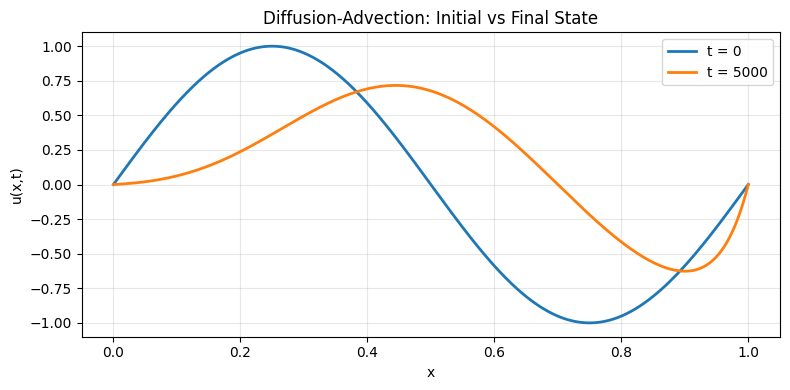

In [3]:
t_plot = n_steps  # or whatever final index you used

plt.figure(figsize=(8,4))
plt.plot(x, data[0], label="t = 0", linewidth=2)
plt.plot(x, data[t_plot], label=f"t = {t_plot}", linewidth=2)
plt.title("Diffusion-Advection: Initial vs Final State")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
def sample_one_B(u, R=5, k=5, max_tries=50, u_scale=None, rng=np.random):
    """
    Sample a single Scheme-B training example using an index-space square.

    Square geometry:
        t in [t0-R, t0+R], x in [x0-R, x0+R]

    Returns:
        feats_flat: (k*3,) with [dt_scaled, dx_scaled, u_scaled]
        target: scalar normalized u(t0,x0)
    """
    Nt, Nx = u.shape

    if u_scale is None:
        u_scale = np.max(np.abs(u)) + 1e-8

    for _ in range(max_tries):

        # ---- 1. sample random center ----
        t0 =  rng.randint(0, Nt)
        x0 =  rng.randint(0, Nx)

        # ---- 2. square bounds ----
        t_min = max(0, t0 - R)
        t_max = min(Nt - 1, t0 + R)
        x_min = max(0, x0 - R)
        x_max = min(Nx - 1, x0 + R)

        # ---- 3. collect candidates ----
        cand = []
        for t in range(t_min, t_max + 1):
            for x in range(x_min, x_max + 1):
                if t == t0 and x == x0:
                    continue
                cand.append((t, x))

        if len(cand) < k:
            continue

        # ---- 4. pick k random neighbors ----
        cand = np.array(cand)
        idx = np.random.choice(len(cand), size=k, replace=False)
        neigh = cand[idx]

        # ---- 5. build feature vector ----
        feats = []
        for (tn, xn) in neigh:
            dt_scaled = (t0 - tn)
            dx_scaled = (x0 - xn)
            u_scaled = u[tn, xn] / u_scale
            feats.append([dt_scaled, dx_scaled, u_scaled])

        feats = np.array(feats, dtype=np.float32).reshape(-1)
        target = np.float32(u[t0, x0] / u_scale)
        return feats, target

    raise RuntimeError("Failed to sample B-example; try changing R/k.")


In [5]:
class BDataset(Dataset):
    """
    Scheme-B dataset:
    - u: PDE solution, shape (Nt, Nx)
    - N_samples: number of samples
    """
    def __init__(self, u, N_samples=50000, R=5, k=5, seed=0, pregenerate=False):
        self.u = u
        self.N_samples = N_samples
        self.R = R
        self.k = k
        self.rng = np.random.RandomState(seed)

        # global normalization for u
        self.u_scale = np.max(np.abs(u)) + 1e-8

        self.pregenerate = pregenerate
        if pregenerate:
            print(f"Pre-generating {N_samples} samples...")
            feats = []
            targets = []

            for i in range(N_samples):
                if (i + 1) % 10000 == 0:
                    print(f"  Generated {i+1}/{N_samples}")

                f, t = sample_one_B(
                    self.u,
                    R=self.R,
                    k=self.k,
                    u_scale=self.u_scale,
                    rng=self.rng,
                )
                feats.append(f)
                targets.append(t)

            self.feats_tensor = torch.from_numpy(
                np.asarray(feats, dtype=np.float32)
            )
            self.targets_tensor = torch.from_numpy(
                np.asarray(targets, dtype=np.float32)
            )

            print("Pre-generation complete.")

    def __len__(self):
        return self.N_samples

    def __getitem__(self, idx):
        if self.pregenerate:
            return self.feats_tensor[idx], self.targets_tensor[idx]
        else:
            feats, target = sample_one_B(
                self.u,
                R=self.R,
                k=self.k,
                u_scale=self.u_scale,
                rng=self.rng,
            )
            return (
                torch.from_numpy(feats),
                torch.tensor(target, dtype=torch.float32),
            )


## Linear predictor (professor's formulation)

**Goal:** Minimize  
$$\min_\Theta \ \|U_{\mathrm{act}} - \sum_{i,j,k} U_{\mathrm{NN}}(i)\, \Delta t^j\, \Delta x^k\, \Theta_{ijk} \|^2 + \lambda \|\Theta\|^2$$

**Steps:**
1. **Predefine a library of variables**  
   Fix exponent ranges, e.g. \(j,k \in \{-2,-1,0,1,2\}\).  
   Each basis term is \(\phi_{jk} = \sum_n U_{\mathrm{NN}}(n)\, \Delta t_n^j\, \Delta x_n^k\) over the \(k\) neighbors.

2. **Build design matrix X and targets y**  
   For each sample (center point + neighbors), one row of X = the 25 library features; y = \(U_{\mathrm{act}}\) at the center.

3. **Optimization (ridge regression)**  
   Solve \(\Theta = (X^\top X + \lambda I)^{-1} X^\top y\). No neural network needed for this linear predictor.

4. **Connection to finite-difference stencil**  
   The 1D diffusion Laplacian uses the stencil **1, -2, 1** (second derivative).  
   With the library, the learned \(\Theta\) for spatial terms (e.g. \(k=-1,0,1\)) can recover stencil-like coefficients, so the model implicitly learns a finite-difference–type structure.

In [6]:
# -----------------------
# Linear predictor: predefined library + ridge optimization
# -----------------------
# Library exponents j, k in {-2,-1,0,1,2} → 25 basis functions
J_LIST = list(range(-2, 3))
K_LIST = list(range(-2, 3))
dx_phys = 1.0 / (Nx - 1)
dt_phys = dt0
n_basis = len(J_LIST) * len(K_LIST)  # 25

def build_library_row(u, t0, x0, neigh, J_LIST, K_LIST, dt_phys, dx_phys):
    """One row of X: for each (j,k), feature = Σ_n U_NN(n) * Δt_n^j * Δx_n^k."""
    row = []
    for j in J_LIST:
        for k in K_LIST:
            val = 0.0
            for (tn, xn) in neigh:
                dt_n = dt_phys * (t0 - tn)
                dx_n = dx_phys * (x0 - xn)
                u_nn = u[tn, xn]
                # avoid 0^negative; use small epsilon for stability
                dt_j = (dt_n ** j) if (j >= 0 or abs(dt_n) > 1e-12) else 0.0
                dx_k = (dx_n ** k) if (k >= 0 or abs(dx_n) > 1e-12) else 0.0
                val += u_nn * dt_j * dx_k
            row.append(val)
    return np.array(row, dtype=np.float64)

def build_X_y_library(u, n_samples, R, k, dt_phys, dx_phys, J_LIST, K_LIST, seed=0):
    """Sample (t0,x0) and k neighbors like BDataset; build X (library features) and y = U_act."""
    rng = np.random.RandomState(seed)
    Nt, Nx = u.shape
    X = np.zeros((n_samples, n_basis))
    y = np.zeros(n_samples)
    for i in range(n_samples):
        for _ in range(100):
            t0 = rng.randint(0, Nt)
            x0 = rng.randint(0, Nx)
            t_min = max(0, t0 - R)
            t_max = min(Nt - 1, t0 + R)
            x_min = max(0, x0 - R)
            x_max = min(Nx - 1, x0 + R)
            cand = [(t, x) for t in range(t_min, t_max + 1) for x in range(x_min, x_max + 1)
                    if not (t == t0 and x == x0)]
            if len(cand) < k:
                continue
            cand = np.array(cand)
            idx = rng.choice(len(cand), size=k, replace=False)
            neigh = [tuple(cand[i]) for i in idx]
            X[i] = build_library_row(u, t0, x0, neigh, J_LIST, K_LIST, dt_phys, dx_phys)
            y[i] = u[t0, x0]
            break
    return X, y

# Build training data for linear predictor
n_samples_lib = 20000
X_lib, y_lib = build_X_y_library(data, n_samples_lib, R=5, k=5, dt_phys=dt_phys, dx_phys=dx_phys,
                                  J_LIST=J_LIST, K_LIST=K_LIST)
print("Library: j in", J_LIST, ", k in", K_LIST, "→", n_basis, "basis functions")
print("X_lib shape:", X_lib.shape, ", y_lib shape:", y_lib.shape)

Library: j in [-2, -1, 0, 1, 2] , k in [-2, -1, 0, 1, 2] → 25 basis functions
X_lib shape: (20000, 25) , y_lib shape: (20000,)


In [7]:
# Ridge regression: min_Θ ||y - X@Θ||^2 + λ||Θ||^2  →  Θ = (X'X + λI)^{-1} X'y
lam = 1e-6  # regularization
XtX = X_lib.T @ X_lib + lam * np.eye(n_basis)
Xty = X_lib.T @ y_lib
Theta_ridge = np.linalg.solve(XtX, Xty)

# Training MSE (linear predictor)
y_pred_lib = X_lib @ Theta_ridge
mse_lib = np.mean((y_lib - y_pred_lib) ** 2)
print(f"Linear predictor (ridge) train MSE = {mse_lib:.6e}")

# Reshape Θ for interpretation: (len(J_LIST), len(K_LIST)) for (j,k) → stencil-like view
Theta_grid = Theta_ridge.reshape(len(J_LIST), len(K_LIST))
print("Learned Θ (rows=j, cols=k); spatial slice j=0, k=-1,0,1 ≈ stencil weights:")
print("  k=-1,0,1:", Theta_grid[J_LIST.index(0), :])  # j=0 row: time-constant, spatial terms

Linear predictor (ridge) train MSE = 1.627684e-04
Learned Θ (rows=j, cols=k); spatial slice j=0, k=-1,0,1 ≈ stencil weights:
  k=-1,0,1: [ 1.18719861e-09 -2.47029183e-08  2.00309555e-01 -3.12408356e-02
 -5.40347192e+00]


In [8]:
# Helper: single-point prediction and eval for the new linear (library+ridge) model
def predict_linear_library(u, t0, x0, neigh, Theta_ridge, J_LIST, K_LIST, dt_phys, dx_phys):
    """Predict u(t0,x0) using library features and Theta_ridge."""
    row = build_library_row(u, t0, x0, neigh, J_LIST, K_LIST, dt_phys, dx_phys)
    return float(np.dot(row, Theta_ridge))

def eval_linear_library(u, Theta_ridge, N_test, R, k, J_LIST, K_LIST, dt_phys, dx_phys, seed=456):
    """Test MSE for the new linear (library+ridge) model."""
    X_test, y_test = build_X_y_library(u, N_test, R, k, dt_phys, dx_phys, J_LIST, K_LIST, seed=seed)
    y_pred = X_test @ Theta_ridge
    return float(np.mean((y_test - y_pred) ** 2))

def build_X_y_feats_for_cumulative(u, n_samples, R, k, dt_phys, dx_phys, J_LIST, K_LIST, u_scale, seed=0):
    """Build X_lib, y_raw, and feats_mlp for the same n_samples (for cumulative error: same points for linear library and MLP)."""
    n_basis = len(J_LIST) * len(K_LIST)
    rng = np.random.RandomState(seed)
    Nt, Nx = u.shape
    X_lib = np.zeros((n_samples, n_basis))
    y_raw = np.zeros(n_samples)
    feats_mlp = np.zeros((n_samples, k * 3), dtype=np.float32)
    for i in range(n_samples):
        for _ in range(100):
            t0 = rng.randint(0, Nt)
            x0 = rng.randint(0, Nx)
            t_min = max(0, t0 - R)
            t_max = min(Nt - 1, t0 + R)
            x_min = max(0, x0 - R)
            x_max = min(Nx - 1, x0 + R)
            cand = [(t, x) for t in range(t_min, t_max + 1) for x in range(x_min, x_max + 1)
                    if not (t == t0 and x == x0)]
            if len(cand) < k:
                continue
            cand = np.array(cand)
            idx = rng.choice(len(cand), size=k, replace=False)
            neigh = [tuple(cand[j]) for j in idx]
            X_lib[i] = build_library_row(u, t0, x0, neigh, J_LIST, K_LIST, dt_phys, dx_phys)
            y_raw[i] = u[t0, x0]
            f = []
            for (tn, xn) in neigh:
                f.extend([t0 - tn, x0 - xn, u[tn, xn] / u_scale])
            feats_mlp[i] = np.array(f, dtype=np.float32)
            break
    return X_lib, y_raw, feats_mlp

In [9]:
class LinearIntegrator(nn.Module):
    def __init__(self, k=5):
        super().__init__()
        self.lin = nn.Linear(k * 3, 1)

    def forward(self, x):
        return self.lin(x).squeeze(-1)


In [10]:
class MLPIntegrator(nn.Module):
    def __init__(self, k=5, hidden=128, num_layers=3):
        super().__init__()
        in_dim = k * 3
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]

        for _ in range(num_layers - 2):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]

        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


In [11]:
def train_integrator_B(
    model,
    u,
    epochs=50,
    batch_size=2048,
    k=5,
    R=5,
    N_samples=100000,
    lr=1e-3,
    pregenerate=True,
):
    """
    Minimal training loop for Scheme-B integrators.

    Args:
        model: torch.nn.Module (linear or MLP)
        u: numpy array (Nt, Nx)
    Returns:
        model: trained model
        train_losses: list of epoch-wise MSE
    """
    device = "cuda"
    model = model.to(device)

    dataset = BDataset(
        u,
        N_samples=N_samples,
        R=R,
        k=k,
        pregenerate=pregenerate,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for feats, target in loader:
            feats = feats.to(device)
            target = target.to(device)

            opt.zero_grad()
            pred = model(feats)
            loss = loss_fn(pred, target)
            loss.backward()
            opt.step()

            total_loss += loss.item() * feats.size(0)

        avg_loss = total_loss / len(dataset)
        train_losses.append(avg_loss)

        print(f"[Epoch {epoch+1}/{epochs}] train MSE = {avg_loss:.6e}")

    return model, train_losses


In [12]:
def eval_integrator_B(model, u, R, k, N_test=10000, batch_size=4096,):
    device = "cuda"
    model.eval()
    test_ds = BDataset( u, N_samples=N_test,R=R,k=k, seed=123,pregenerate=True,    )
    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0,pin_memory=True,)
    loss_fn = nn.MSELoss()
    total_loss = 0.0
    with torch.no_grad():
        for feats, target in loader:
            feats = feats.to(device)
            target = target.to(device)
            pred = model(feats)
            loss = loss_fn(pred, target)
            total_loss += loss.item() * feats.size(0)
    avg_loss = total_loss / N_test
    print(f"[Eval] MSE = {avg_loss:.6e}")
    return avg_loss

In [13]:
def visualize_B_compare_models(u, model_mlp, R=5, k=5, Theta_ridge=None, J_LIST=None, K_LIST=None, dt_phys=None, dx_phys=None):
    """Compare new linear (library+ridge) vs MLP. Pass Theta_ridge and library params for the linear model."""
    device = "cuda"
    model_mlp.eval()

    # Use same k as model (avoids shape mismatch if R,k changed after training)
    if hasattr(model_mlp, "net"):
        k = model_mlp.net[0].in_features // 3
    elif hasattr(model_mlp, "lin"):
        k = model_mlp.lin.in_features // 3

    Nt, Nx = u.shape

    # ---- choose one random center ----
    t0 = np.random.randint(0, Nt)
    x0 = np.random.randint(0, Nx)

    # ---- square neighborhood ----
    t_min = max(0, t0 - R)
    t_max = min(Nt - 1, t0 + R)
    x_min = max(0, x0 - R)
    x_max = min(Nx - 1, x0 + R)

    cand = [(t, x) for t in range(t_min, t_max + 1)
                    for x in range(x_min, x_max + 1)
                    if not (t == t0 and x == x0)]
    cand = np.array(cand)
    if len(cand) < k:
        raise ValueError(f"Not enough neighbors: need k={k} but square has {len(cand)}. Increase R.")

    idx = np.random.choice(len(cand), size=k, replace=False)
    neigh = cand[idx]
    neigh_tuples = [tuple(cand[i]) for i in idx]

    # ---- linear (library+ridge): pred from library features ----
    if Theta_ridge is not None and J_LIST is not None and K_LIST is not None and dt_phys is not None and dx_phys is not None:
        pred_lin = predict_linear_library(u, t0, x0, neigh_tuples, Theta_ridge, J_LIST, K_LIST, dt_phys, dx_phys)
    else:
        pred_lin = np.nan

    # ---- MLP: 15-dim feats ----
    u_scale = np.max(np.abs(u)) + 1e-8
    feats = []
    for (tn, xn) in neigh:
        feats.append([t0 - tn, x0 - xn, u[tn, xn] / u_scale])
    feats = np.array(feats, dtype=np.float32).reshape(1, -1)
    feats_torch = torch.from_numpy(feats).to(device)

    with torch.no_grad():
        pred_mlp = model_mlp(feats_torch).item() * u_scale

    true = u[t0, x0]

    # ---- plotting ----
    fig, axes = plt.subplots(
        1, 2,
        figsize=(9, 4),
        sharey=True,
        gridspec_kw={"wspace": 0.08},  # panels closer
    )

    for ax, title, pred in zip(
        axes,
        ["Linear (library+ridge)", "MLP"],
        [pred_lin, pred_mlp],
    ):
        # square
        rect = plt.Rectangle(
            (x_min, t_min),
            x_max - x_min,
            t_max - t_min,
            fill=False,
            edgecolor="blue",
            linewidth=1.8,
        )
        ax.add_patch(rect)

        # neighbors
        ax.scatter(neigh[:, 1], neigh[:, 0], s=110, label="neighbors")
        for (tn, xn) in neigh:
            ax.plot([x0, xn], [t0, tn], alpha=0.6)

        # target
        ax.scatter([x0], [t0], c="red", s=180, label="target", zorder=5)

        err = (true - pred)  if not np.isnan(pred) else float('nan')
        ax.set_title(
            f"{title}\n"
            f"pred = {pred:.5f}, error = {err:.4f}",
            fontsize=10,
        )

        ax.set_xlim(x_min - 2, x_max + 2)
        ax.set_ylim(t_max + 2, t_min - 2)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x")
    for ax in axes:
        ax.invert_yaxis()
    axes[0].set_ylabel("t (time index, upward)")

    # ---- shared legend ----
    handles, labels = axes[0].get_legend_handles_labels()
     

    # ---- shared true value ----
    fig.suptitle(
        f"True value at target: u(t₀, x₀) = {true:.5f}",
        y=1.05,
        fontsize=11,
    )
    # Flip y-axis to have increasing upward
    
    plt.tight_layout()
    plt.show()


In [14]:
def save_integrator_model(model, model_type, path, config):
    """
    Save a trained integrator model.

    Args:
        model: trained torch.nn.Module
        model_type: str ("linear" or "mlp")
        config: dict with required hyperparameters
    """
    torch.save(
        {
            "model_type": model_type,
            "model_state_dict": model.state_dict(),
            "config": config,
        },
        path,
    )


In [15]:
def load_integrator_model(path):
    """
    Load a saved integrator model.
    """
    device = "cuda"
    checkpoint = torch.load(path, map_location=device)

    model_type = checkpoint["model_type"]
    config = checkpoint["config"]

    if model_type == "linear":
        model = LinearIntegrator(k=config["k"])
    elif model_type == "mlp":
        model = MLPIntegrator(
            k=config["k"],
            hidden=config["hidden"],
            num_layers=config["num_layers"],
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model, config


In [16]:
# =========================
# Experiments
# =========================
 
R = 5
k = 5
epochs = 150
batch_size = 2048
N_samples = 100000
lr = 1e-3

In [17]:
 
# Train MLP (saved as diffusion_advection_mlp_model.pt for rollout)
model_mlp = MLPIntegrator(k=k, hidden=128, num_layers=3)
model_mlp, loss_mlp = train_integrator_B(
    model_mlp,
    data,
    epochs=epochs,
    batch_size=batch_size,
    k=k,
    R=R,
    N_samples=N_samples,
    lr=lr,
)


Pre-generating 100000 samples...
  Generated 10000/100000
  Generated 20000/100000
  Generated 30000/100000
  Generated 40000/100000
  Generated 50000/100000
  Generated 60000/100000
  Generated 70000/100000
  Generated 80000/100000
  Generated 90000/100000
  Generated 100000/100000
Pre-generation complete.
[Epoch 1/150] train MSE = 6.299416e-02
[Epoch 2/150] train MSE = 4.491053e-03
[Epoch 3/150] train MSE = 3.149625e-03
[Epoch 4/150] train MSE = 2.456348e-03
[Epoch 5/150] train MSE = 2.000272e-03
[Epoch 6/150] train MSE = 1.674295e-03
[Epoch 7/150] train MSE = 1.428109e-03
[Epoch 8/150] train MSE = 1.256746e-03
[Epoch 9/150] train MSE = 1.108726e-03
[Epoch 10/150] train MSE = 9.799419e-04
[Epoch 11/150] train MSE = 9.098629e-04
[Epoch 12/150] train MSE = 8.079295e-04
[Epoch 13/150] train MSE = 7.214694e-04
[Epoch 14/150] train MSE = 6.612087e-04
[Epoch 15/150] train MSE = 5.995569e-04
[Epoch 16/150] train MSE = 5.583622e-04
[Epoch 17/150] train MSE = 5.204720e-04
[Epoch 18/150] train

In [18]:
# New linear (library+ridge)
test_loss_linear_lib = eval_linear_library(data, Theta_ridge, N_test=20_000, R=R, k=k,
    J_LIST=J_LIST, K_LIST=K_LIST, dt_phys=dt_phys, dx_phys=dx_phys)
print(f"[Eval] Linear (library+ridge) MSE = {test_loss_linear_lib:.6e}")

# MLP
test_loss_mlp = eval_integrator_B(model_mlp, data, R=R, k=k, N_test=20_000)

print(f"Linear (library+ridge) test MSE: {test_loss_linear_lib:.6e}")
print(f"MLP test MSE:                    {test_loss_mlp:.6e}")


[Eval] Linear (library+ridge) MSE = 1.454002e-04
Pre-generating 20000 samples...
  Generated 10000/20000
  Generated 20000/20000
Pre-generation complete.
[Eval] MSE = 1.596689e-04
Linear (library+ridge) test MSE: 1.454002e-04
MLP test MSE:                    1.596689e-04


In [19]:
R
k

5

In [20]:
# ===== Save models (rollout filenames: diffusion_advection_linear_model.pt, diffusion_advection_mlp_model.pt) =====
u_scale = np.max(np.abs(data)) + 1e-8
config_lin = {"k": k, "R": R, "u_scale": u_scale}
config_mlp = {"k": k, "R": R, "hidden": 128, "num_layers": 3, "u_scale": u_scale}

save_integrator_model(model_lin, "linear", "diffusion_advection_linear_model.pt", config_lin)
save_integrator_model(model_mlp, "mlp", "diffusion_advection_mlp_model.pt", config_mlp)

print("Models saved: diffusion_advection_linear_model.pt, diffusion_advection_mlp_model.pt")


NameError: name 'model_lin' is not defined

In [ ]:
# ===== Load models (same filenames as rollout) =====
model_lin, config_lin = load_integrator_model("diffusion_advection_linear_model.pt")
model_mlp, config_mlp = load_integrator_model("diffusion_advection_mlp_model.pt")
print("Loaded linear and MLP integrators.")


Loaded linear and MLP integrators.


C:\Users\amt35\AppData\Local\Temp\ipykernel_5476\1740663133.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


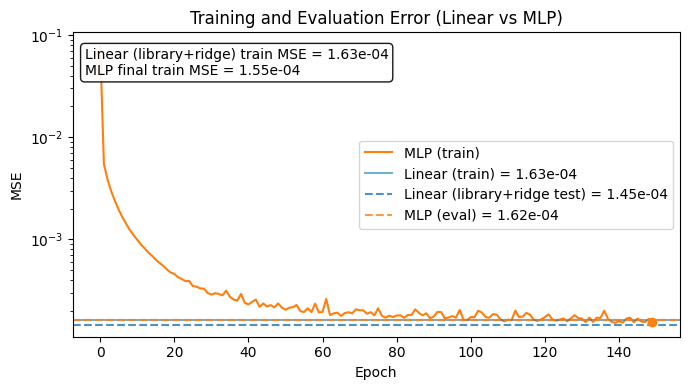

In [ ]:
plt.figure(figsize=(7, 4))

# MLP training curve (linear = library+ridge has no iterative training)
plt.semilogy(loss_mlp, label="MLP (train)", color="C1")

# Mark final MLP point
final_mlp = loss_mlp[-1]
epoch_last = len(loss_mlp) - 1
plt.scatter(epoch_last, final_mlp, color="C1", zorder=5)

# Linear (library+ridge): single train MSE and test horizontal line
plt.axhline(mse_lib, color="C0", linestyle="-", alpha=0.6, label=f"Linear (train) = {mse_lib:.2e}")
plt.axhline(
    test_loss_linear_lib,
    color="C0",
    linestyle="--",
    alpha=0.8,
    label=f"Linear (library+ridge test) = {test_loss_linear_lib:.2e}"
)
plt.axhline(
    test_loss_mlp,
    color="C1",
    linestyle="--",
    alpha=0.8,
    label=f"MLP (eval) = {test_loss_mlp:.2e}"
)

# ---- Text box: Linear = library+ridge (no train curve), MLP = final train ----
textstr = (
    f"Linear (library+ridge) train MSE = {mse_lib:.2e}\n"
    f"MLP final train MSE = {final_mlp:.2e}"
)

plt.text(
    0.02, 0.95, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Evaluation Error (Linear vs MLP)")
plt.legend()
plt.grid(False)   # <-- remove grey grid lines
plt.tight_layout()
plt.show()


C:\Users\amt35\AppData\Local\Temp\ipykernel_5476\857936796.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


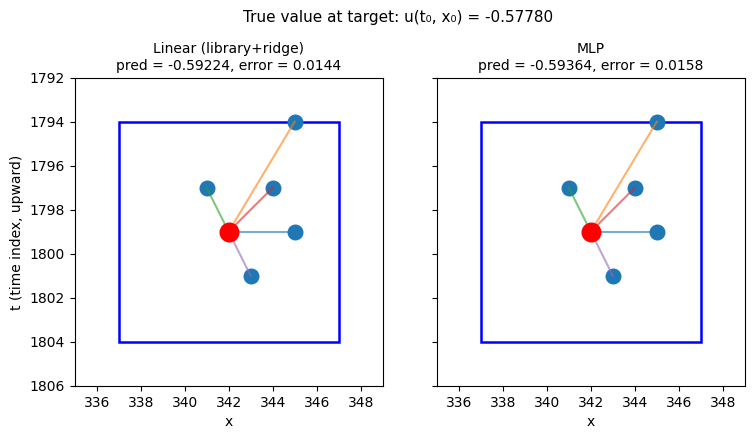

In [ ]:
visualize_B_compare_models(data, model_mlp, R=R, k=k,
    Theta_ridge=Theta_ridge, J_LIST=J_LIST, K_LIST=K_LIST, dt_phys=dt_phys, dx_phys=dx_phys)



Using k=5, R=5


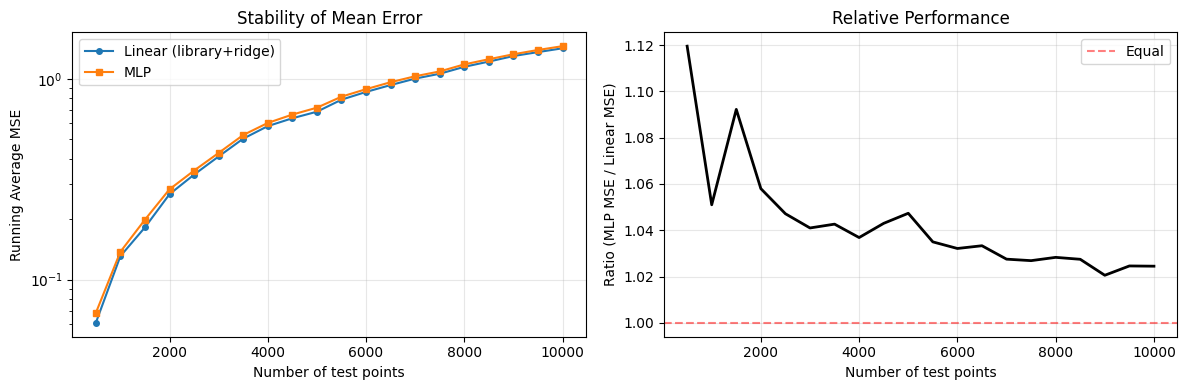

In [23]:
# --- Reset Hyperparameters to ensure they are positive ---
R = 5
k = 5 
n_points = 10000
step = 500

# Verify k is what we expect
print(f"Using k={k}, R={R}")

# Now run the data generation
X_lib, y_raw, feats_mlp = build_X_y_feats_for_cumulative(
    data, n_points, R, k, dt_phys, dx_phys, J_LIST, K_LIST, u_scale, seed=456
)
X_lib, y_raw, feats_mlp = build_X_y_feats_for_cumulative(
    data, n_points, R, k, dt_phys, dx_phys, J_LIST, K_LIST, u_scale, seed=456
)

cum_mse_lin, cum_mse_mlp = [], []
total_se_lin, total_se_mlp = 0.0, 0.0

model_mlp.eval()
with torch.no_grad():
    for i in range(0, n_points, step):
        end = min(i + step, n_points)
        
        # Predictions
        pred_lin = X_lib[i:end] @ Theta_ridge
        feats_batch = torch.from_numpy(feats_mlp[i:end]).to(device)
        pred_mlp_raw = model_mlp(feats_batch).cpu().numpy() * u_scale
        
        y_batch = y_raw[i:end]
        
        # Accumulate Squared Error (SE)
        total_se_lin += np.sum((y_batch - pred_lin) ** 2)
        total_se_mlp += np.sum((y_batch - pred_mlp_raw) ** 2)
        
        # Calculate RUNNING MEAN (MSE)
        num_processed = end 
        cum_mse_lin.append(total_se_lin  )
        cum_mse_mlp.append(total_se_mlp )

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
x_axis = np.arange(step, n_points + 1, step)

# Plot 1: Running MSE (Average error as we see more data)
ax1.plot(x_axis, cum_mse_lin, 'o-', label='Linear (library+ridge)', color='C0', markersize=4)
ax1.plot(x_axis, cum_mse_mlp, 's-', label='MLP', color='C1', markersize=4)
ax1.set_yscale('log') # Better for seeing small differences
ax1.set_xlabel('Number of test points')
ax1.set_ylabel('Running Average MSE')
ax1.set_title('Stability of Mean Error')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Error ratio
ratio = np.array(cum_mse_mlp) / np.array(cum_mse_lin)
ax2.plot(x_axis, ratio, 'k-', linewidth=2)
ax2.axhline(1, color='r', linestyle='--', alpha=0.5, label='Equal')
ax2.set_xlabel('Number of test points')
ax2.set_ylabel('Ratio (MLP MSE / Linear MSE)')
ax2.set_title('Relative Performance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Inspect learned linear library (Theta_ridge)
# ============================================

import numpy as np

# --- user-adjustable threshold ---
tol = 1e-6   # coefficients smaller than this are considered zero

Theta = Theta_ridge.copy()

print("=== Learned linear model ===")
print(f"Total library terms: {Theta.size}")
print(f"Threshold for 'surviving' terms: {tol:e}")
print()

terms = []

for idx, theta in enumerate(Theta):
    if abs(theta) > tol:
        j = J_LIST[idx // len(K_LIST)]
        k = K_LIST[idx %  len(K_LIST)]
        terms.append((theta, j, k))

# sort by magnitude
terms.sort(key=lambda x: abs(x[0]), reverse=True)

print(f"Surviving terms: {len(terms)}\n")

for theta, j, k in terms:
    jt = f"(Δt)^{j}" if j != 0 else "1"
    kt = f"(Δx)^{k}" if k != 0 else "1"
    print(f"Θ = {theta:+.4e} · Σ_n u_n · {jt} · {kt}")

# --- write the model explicitly ---
print("\n=== Model form ===")
print("û(t₀,x₀) = Σ over surviving (j,k) of:")
print("    Θ_{j,k} · Σ_n [ u(t_n,x_n) · (Δt_n)^j · (Δx_n)^k ]")


=== Learned linear model ===
Total library terms: 25
Threshold for 'surviving' terms: 1.000000e-06

Surviving terms: 14

Θ = -5.4035e+00 · Σ_n u_n · 1 · (Δx)^2
Θ = +1.1828e+00 · Σ_n u_n · (Δt)^2 · (Δx)^-1
Θ = -4.3262e-01 · Σ_n u_n · (Δt)^1 · 1
Θ = +2.0031e-01 · Σ_n u_n · 1 · 1
Θ = +6.4953e-02 · Σ_n u_n · (Δt)^1 · (Δx)^1
Θ = +5.0840e-02 · Σ_n u_n · (Δt)^2 · 1
Θ = -3.1241e-02 · Σ_n u_n · 1 · (Δx)^1
Θ = +1.1653e-02 · Σ_n u_n · (Δt)^1 · (Δx)^2
Θ = -5.6817e-03 · Σ_n u_n · (Δt)^2 · (Δx)^-2
Θ = -4.3582e-04 · Σ_n u_n · (Δt)^2 · (Δx)^1
Θ = +3.4027e-04 · Σ_n u_n · (Δt)^-1 · (Δx)^2
Θ = -1.3503e-04 · Σ_n u_n · (Δt)^1 · (Δx)^-1
Θ = +4.6319e-06 · Σ_n u_n · (Δt)^2 · (Δx)^2
Θ = +1.5520e-06 · Σ_n u_n · (Δt)^1 · (Δx)^-2

=== Model form ===
û(t₀,x₀) = Σ over surviving (j,k) of:
    Θ_{j,k} · Σ_n [ u(t_n,x_n) · (Δt_n)^j · (Δx_n)^k ]
